In [1]:
# -*- coding: utf-8 -*-
# experiments.ipynb - Main execution notebook

# Environment setup
import os
import time
import joblib
import pandas as pd
from sklearn.metrics import (roc_auc_score)

# Local module imports
from dataset import preprocess_data
from model import HybridRiskModel
from eval import (analyze_performance, bootstrap_metric_comparison,
                  interpret_shap, plot_comparative_metrics)
from configs import (MODEL_SAVE_PATH, RANDOM_STATE)

# Set reproducibility
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

In [2]:
# Data preparation
X_train, X_test, y_train, y_test = preprocess_data()

In [ ]:
# Ablation study configurations
ablation_configs = [
    {"use_segmentation": True, "use_feature_selection": True},
    {"use_segmentation": False, "use_feature_selection": True},
    {"use_segmentation": True, "use_feature_selection": False}
]


=== Training Seg:True_FS:True ===


c:\Users\dipes\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


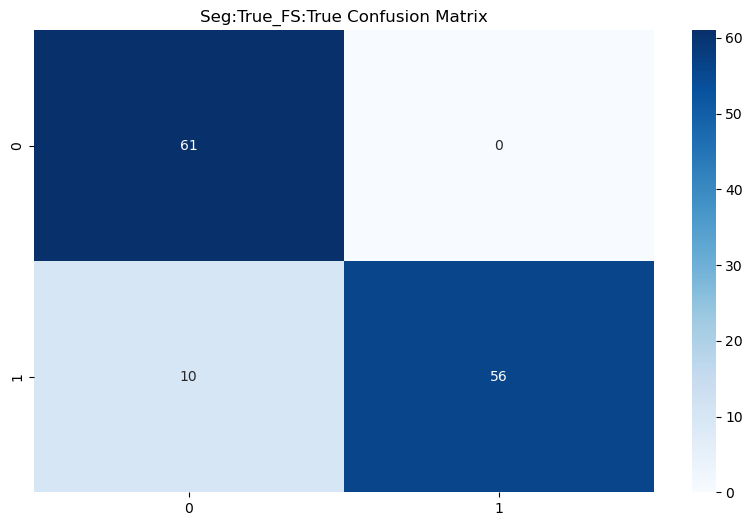


=== Training Seg:False_FS:True ===


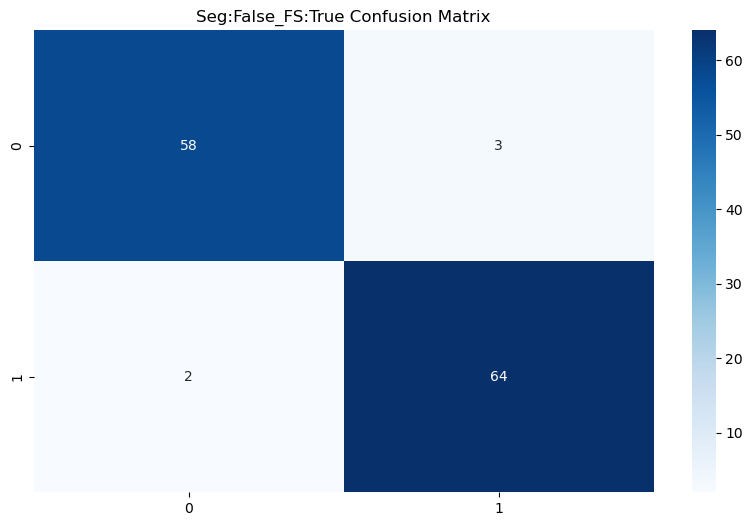


=== Training Seg:True_FS:False ===
Error training Seg:True_FS:False: object of type 'NoneType' has no len()

=== Training Seg:False_FS:False ===
Error training Seg:False_FS:False: object of type 'NoneType' has no len()


c:\Users\dipes\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [4]:
# Run ablation study
ablation_results = []
models = {}

for config in ablation_configs:
    config_str = f"Seg:{config['use_segmentation']}_FS:{config['use_feature_selection']}"
    print(f"\n=== Training {config_str} ===")

    try:
        start_time = time.time()
        model = HybridRiskModel(**config)
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        y_pred = model.predict(X_test)
        metrics = analyze_performance(y_test, y_pred, config_str)

        metrics.update({
            'Time': train_time,
            'Model': config_str
        })
        ablation_results.append(metrics)
        models[config_str] = model

    except Exception as e:
        print(f"Error training {config_str}: {str(e)}")
        continue

In [5]:
# Results analysis
results_df = pd.DataFrame(ablation_results).set_index('Model')
print("\nPerformance Comparison:")
display(results_df)


Performance Comparison:


,Accuracy,Precision,Recall,F1,AUC,Time
Model,,,,,,
Seg:True_FS:True,0.92126,1.000000,0.848485,0.918033,0.924242,7.039803
Seg:False_FS:True,0.96063,0.955224,0.969697,0.962406,0.960258,1.731700


In [6]:
# Statistical testing
full_pred = models['Seg:True_FS:True'].predict(X_test)
no_seg_pred = models['Seg:False_FS:True'].predict(X_test)

t_stat, p_value, ci_lower, ci_upper, mean_diff = bootstrap_metric_comparison(
    y_test.values, full_pred, no_seg_pred, roc_auc_score
)

In [7]:
print("\nBootstrap Analysis (Full vs No Segmentation):")
print(f"Mean AUC Difference: {mean_diff:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"p-value: {p_value:.4f}")


Bootstrap Analysis (Full vs No Segmentation):
Mean AUC Difference: -0.0349
95% CI: [-0.0827, 0.0121]
p-value: 0.0000


SHAP Feature Importance Summary:
            Feature  Mean_Abs_SHAP
6  Purpose_radio/TV       0.962017
0        Sex_female       0.126006
4       Housing_own       0.099824
7           Segment       0.029331
1          Sex_male       0.026355
5      Housing_rent       0.016166
3      Housing_free       0.012880
2           Sex_nan       0.000000


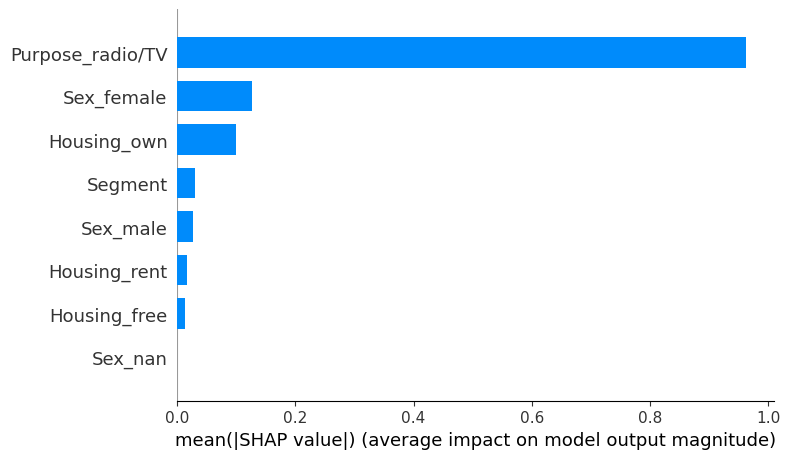

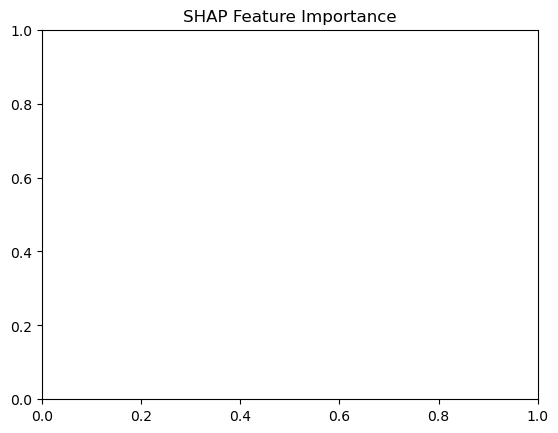

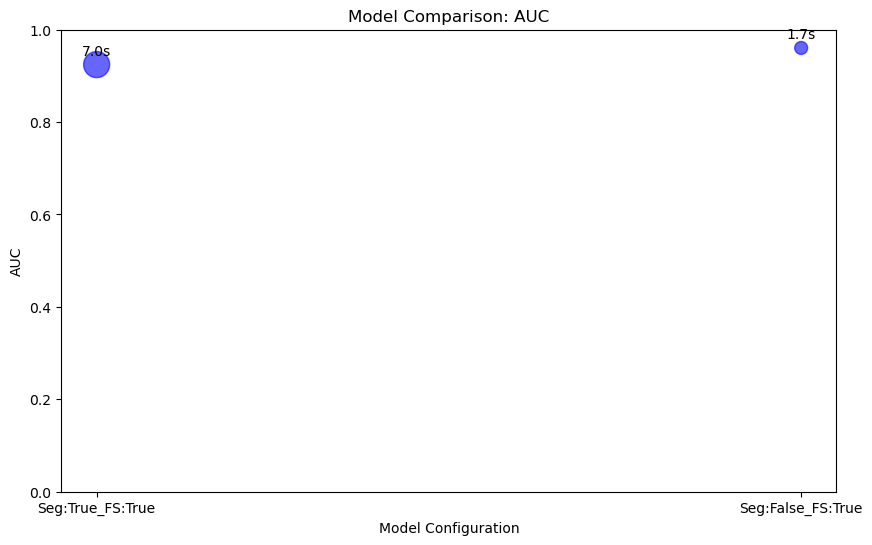

In [8]:
# Model interpretation
best_model = models['Seg:True_FS:True']
interpret_shap(best_model, X_test)
plot_comparative_metrics(ablation_results, 'AUC')

In [9]:
# Save best model
joblib.dump(best_model, MODEL_SAVE_PATH)
print(f"\nBest model saved to {MODEL_SAVE_PATH}")


Best model saved to models/hybrid_credit_model.pkl
